## Comparing CLIP Model Outputs

### OBJECTIVE: Analyze marginal utility of fine-tuned model weights in making roofing material predictions on (labeled) test images.

In [2]:
#@title Imports
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
import torch
import open_clip
from torchvision import transforms
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download


In [ ]:
#@title Material Descriptions and CSV Loading
# EDIT TO GENERATE RESULTS FOR HOLDOUT SET ALONE OR FULL TEST SET

model_name = 'ViT-L-14' # ['RN50', 'ViT-B-32', 'ViT-L-14']

# Load test CSV
csv_path = "../resources/roofnet_metadata.csv"  # Adjust path as needed
df = pd.read_csv(csv_path)

# ONLY HOLDOUT SET
# df = df[df['split']=='holdout']

# FULL TEST SET
df = df[~df['split']=='train']

In [ ]:
# Class prompts
material_descriptions = {
    "Thatch": "thatch roof",
    "GreenVegetative": "roof with vegetation on it",
    "StoneSlates": "dark stone slate roof",
    "ClayTiles": "clay tile / ceramic tile roof",
    "AsphaltTiles": "asphalt shingle pitched roof",
    "ConcreteTiles": "tiled concrete / tiled cement roof",
    "WoodTiles": "wood shingle roof",
    "MetalSheetMaterials": "corrugated or tiled metal roof (silver / dark / painted)",
    "PolycarbonateSheetMaterials": "polycarbonate roof",
    "GlassSheetMaterials": "glass roof (clear or mirrored)",
    "AmorphousConcrete": "flat concrete / cement roof",
    "AmorphousAsphalt": "asphalt-coated roof (bitumen layer or rolled roofing)",
    "AmorphousMembrane": "membrane roof (bright EPDM / TPO)",
    "AmorphousFabric": "tensile fabric roof (PVC / PTFE / canvas)",
    "Unknown": "unknown material, image may be too low resolution or obstructed"
}
classes = list(material_descriptions.keys())
prompts = list(material_descriptions.values())


100%|██████████| 44300/44300 [2:19:38<00:00,  5.29it/s]  



✅ CLIP Top-1 Accuracy: 40.30% (17853/44300)


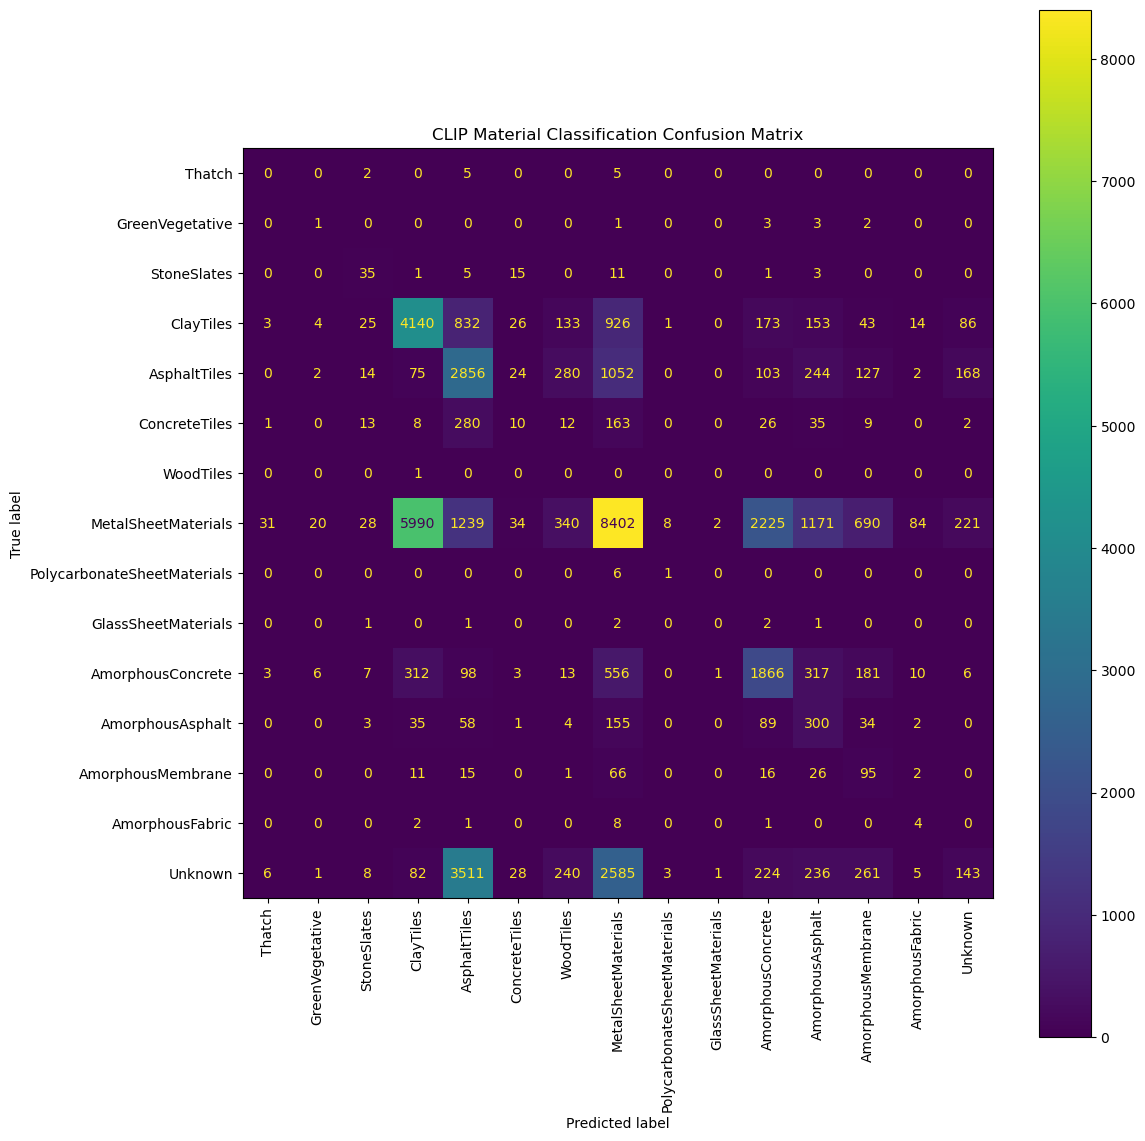

In [ ]:
#@title Test RoofNet Fine-tuned RemoteCLIP Model
model, preprocess_train, preprocess = open_clip.create_model_and_transforms(model_name)
tokenizer = open_clip.get_tokenizer(model_name)

ckpt = torch.load('../resources/best_clip_model_balanced.pth')
message = model.load_state_dict(ckpt)
print(message)

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
classes = list(material_descriptions.keys())
prompts = list(material_descriptions.values())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

# Encode prompts
with torch.no_grad():
    text_tokens = tokenizer(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Evaluate
correct = 0
total = 0
true_labels = []
pred_labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = '../roofnet_data_split/val/' + row["filename"]
    true_class = row["material_class"]

    if not os.path.exists(img_path):
        continue

    image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        sims = image_features @ text_features.T
        pred_class = classes[sims.argmax().item()]

    true_labels.append(class_to_idx[true_class])
    pred_labels.append(class_to_idx[pred_class])

# === Compute Accuracy ===
correct = sum([t == p for t, p in zip(true_labels, pred_labels)])
total = len(true_labels)
print(f"\n✅ CLIP Top-1 Accuracy: {correct / total * 100:.2f}% ({correct}/{total})")

# === Generate and Plot Confusion Matrix ===
cm = confusion_matrix(true_labels, pred_labels, labels=list(range(len(classes))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(xticks_rotation=90, ax=ax, cmap='viridis')
plt.title("CLIP Material Classification Confusion Matrix")
plt.tight_layout()
plt.show()

/var/folders/v8/9cfy1gdx1sld3kvlqhb266v80000gn/T/ipykernel_16294/161722188.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_locatio

<All keys matched successfully>


100%|██████████| 44300/44300 [1:51:42<00:00,  6.61it/s]  



✅ CLIP Top-1 Accuracy: 9.85% (4362/44300)


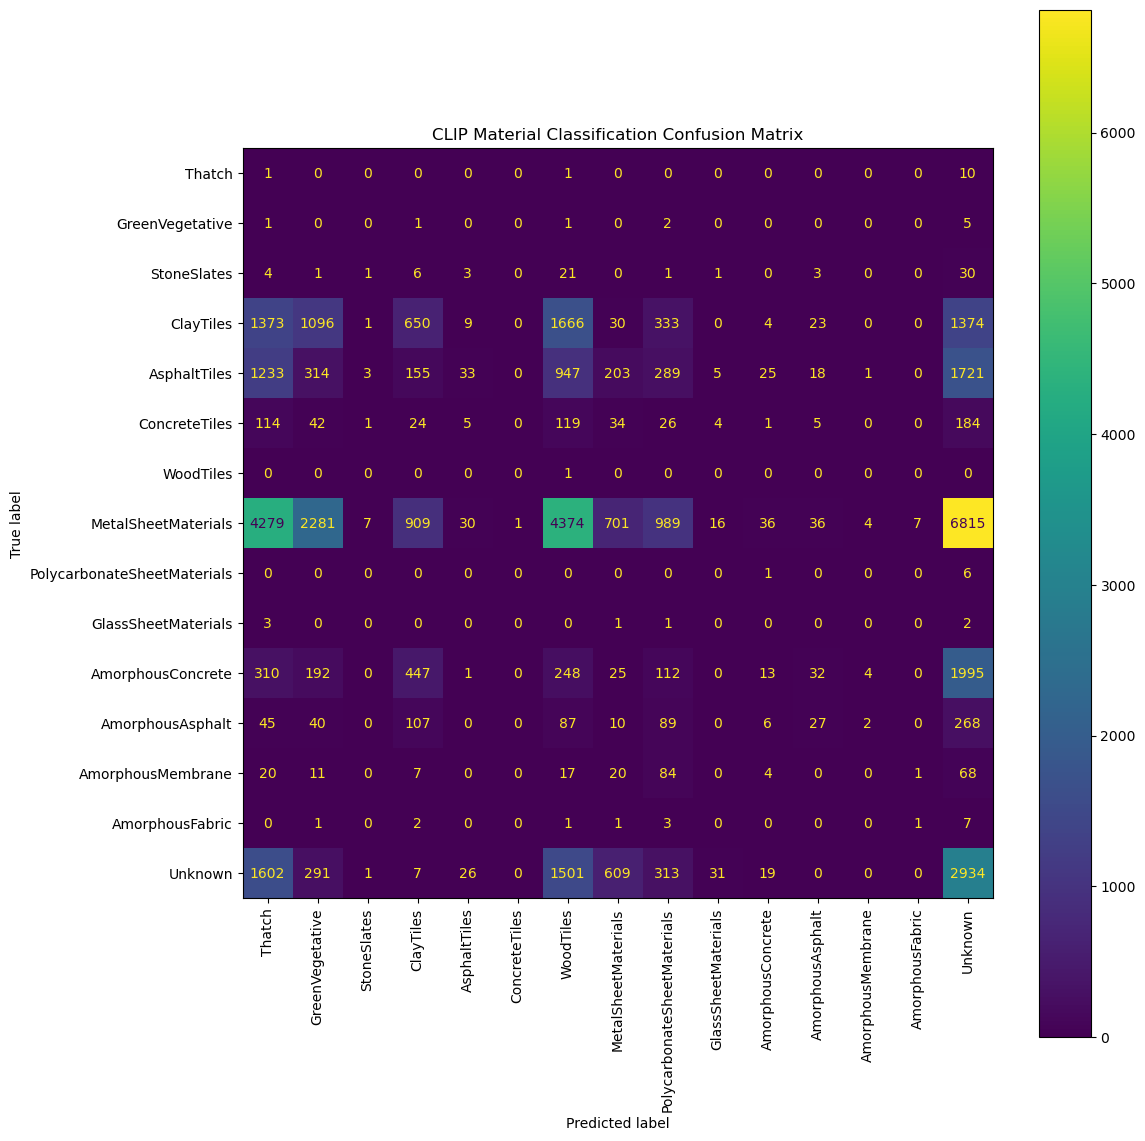

In [24]:
#@title Test RemoteCLIP OOB ViT-14/L
model, preprocess_train, preprocess = open_clip.create_model_and_transforms(model_name)
tokenizer = open_clip.get_tokenizer(model_name)

checkpoint_path = hf_hub_download("chendelong/RemoteCLIP", f"RemoteCLIP-{model_name}.pt", cache_dir='checkpoints')
ckpt = torch.load(checkpoint_path, map_location="cpu")
message = model.load_state_dict(ckpt)
print(message)

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
classes = list(material_descriptions.keys())
prompts = list(material_descriptions.values())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

# Encode prompts
with torch.no_grad():
    text_tokens = tokenizer(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Evaluate
correct = 0
total = 0
true_labels = []
pred_labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = '../roofnet_data_split/val/' + row["filename"]
    true_class = row["material_class"]

    if not os.path.exists(img_path):
        continue

    image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        sims = image_features @ text_features.T
        pred_class = classes[sims.argmax().item()]

    true_labels.append(class_to_idx[true_class])
    pred_labels.append(class_to_idx[pred_class])

# === Compute Accuracy ===
correct = sum([t == p for t, p in zip(true_labels, pred_labels)])
total = len(true_labels)
print(f"\n✅ CLIP Top-1 Accuracy: {correct / total * 100:.2f}% ({correct}/{total})")

# === Generate and Plot Confusion Matrix ===
cm = confusion_matrix(true_labels, pred_labels, labels=list(range(len(classes))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(xticks_rotation=90, ax=ax, cmap='viridis')
plt.title("CLIP Material Classification Confusion Matrix")
plt.tight_layout()

100%|██████████| 44300/44300 [2:18:02<00:00,  5.35it/s]  



✅ CLIP Top-1 Accuracy: 1.08% (478/44300)


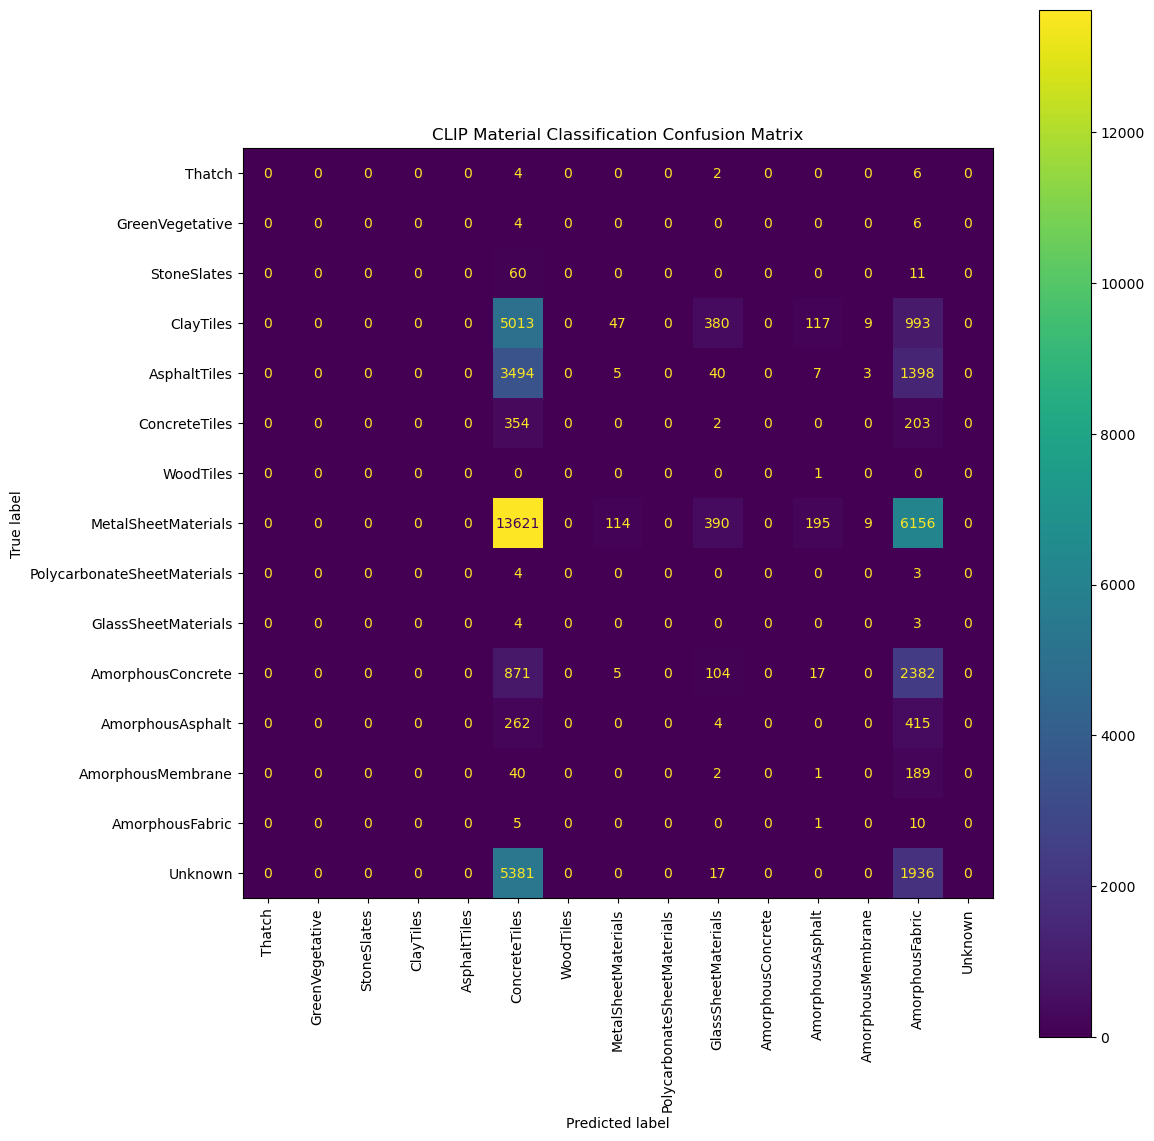

In [20]:
#@title Test CLIP OOB ViT-14/L
model, preprocess_train, preprocess = open_clip.create_model_and_transforms(model_name)
tokenizer = open_clip.get_tokenizer(model_name)

# Load CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
classes = list(material_descriptions.keys())
prompts = list(material_descriptions.values())
class_to_idx = {cls: i for i, cls in enumerate(classes)}

# Encode prompts
with torch.no_grad():
    text_tokens = tokenizer(prompts).to(device)
    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

# Evaluate
correct = 0
total = 0
true_labels = []
pred_labels = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = '../roofnet_data_split/val/' + row["filename"]
    true_class = row["material_class"]

    if not os.path.exists(img_path):
        continue

    image = preprocess(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        sims = image_features @ text_features.T
        pred_class = classes[sims.argmax().item()]

    true_labels.append(class_to_idx[true_class])
    pred_labels.append(class_to_idx[pred_class])

# === Compute Accuracy ===
correct = sum([t == p for t, p in zip(true_labels, pred_labels)])
total = len(true_labels)
print(f"\n✅ CLIP Top-1 Accuracy: {correct / total * 100:.2f}% ({correct}/{total})")

# === Generate and Plot Confusion Matrix ===
cm = confusion_matrix(true_labels, pred_labels, labels=list(range(len(classes))))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(xticks_rotation=90, ax=ax, cmap='viridis')
plt.title("CLIP Material Classification Confusion Matrix")
plt.tight_layout()